In [2]:
import numpy as np
import pandas as pd 

import os

# CBIS DATASET

In [3]:
Monday=pd.read_csv('../data/monday.csv',encoding='latin1', sep=",")
Tuesday=pd.read_csv('../data/tuesday.csv',encoding='latin1', sep=",")
Wednesday=pd.read_csv('../data/wednesday.csv',encoding='latin1', sep=",")
Thursday=pd.read_csv('../data/thursday.csv', sep=",")
Friday=pd.read_csv('../data/friday.csv',encoding='latin1', sep=",")

In [4]:
dim_Monday = Monday.shape
dim_Tuesday = Tuesday.shape
dim_Wednesday = Wednesday.shape
dim_Thursday = Thursday.shape
dim_Friday = Friday.shape


print(f"Dimensions of Monday dataset: {dim_Monday[0]} rows, {dim_Monday[1]} columns")
print(f"Dimensions of Tuesday dataset: {dim_Tuesday[0]} rows, {dim_Tuesday[1]} columns")
print(f"Dimensions of Wednesday dataset: {dim_Wednesday[0]} rows, {dim_Wednesday[1]} columns")
print(f"Dimensions of Thursday dataset: {dim_Thursday[0]} rows, {dim_Thursday[1]} columns")
print(f"Dimensions of Friday dataset: {dim_Friday[0]} rows, {dim_Friday[1]} columns")


Dimensions of Monday dataset: 371624 rows, 91 columns
Dimensions of Tuesday dataset: 322078 rows, 91 columns
Dimensions of Wednesday dataset: 757584 rows, 91 columns
Dimensions of Thursday dataset: 362076 rows, 91 columns
Dimensions of Friday dataset: 547557 rows, 91 columns


In [5]:
data1 = pd.concat([Monday, Tuesday, Wednesday, Thursday])
data1.head(5)

,id,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,...,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,ICMP Code,ICMP Type,Total TCP Flow Time,Label,Attempted Category
0,1,8.6.0.1-8.0.6.4-0-0-0,8.6.0.1,0,8.0.6.4,0,0,2017-07-03 11:56:34.157427,119719148,231,...,17,12685486.0,5.296658e+06,20694308,6499982,-1,-1,0,BENIGN,-1
1,2,192.168.10.9-192.168.10.3-123-123-17,192.168.10.9,123,192.168.10.3,123,17,2017-07-03 11:56:55.428911,65511209,6,...,1506210,64004884.0,0.000000e+00,64004884,64004884,-1,-1,0,BENIGN,-1
2,3,192.168.10.12-224.0.0.251-5353-5353-17,192.168.10.12,5353,224.0.0.251,5353,17,2017-07-03 11:57:21.057686,113976922,267,...,14,25498178.0,1.883305e+07,48523116,5463561,-1,-1,0,BENIGN,-1
3,4,192.168.10.12-152.2.133.52-123-123-17,192.168.10.12,123,152.2.133.52,123,17,2017-07-03 11:57:31.568196,67037196,8,...,11034681,55956316.0,0.000000e+00,55956316,55956316,-1,-1,0,BENIGN,-1
4,5,192.168.10.12-45.79.11.217-123-123-17,192.168.10.12,123,45.79.11.217,123,17,2017-07-03 11:57:30.571719,68045057,8,...,11043596,56943904.0,0.000000e+00,56943904,56943904,-1,-1,0,BENIGN,-1


In [6]:
data1.to_csv("train.csv",sep=",", index=False)

In [ ]:
# Check for duplicates
duplicates2 = data1[data1.duplicated()]

if not duplicates2.empty:
    print("Duplicates found:")
    print(duplicates2)
    
    print("\nShape of duplicates:")
    print(duplicates2.shape)
    
    data1_no_duplicates = data1.drop_duplicates()
    
    print("\nShape of DataFrame after dropping duplicates:")
    print(data1_no_duplicates.shape)
else:
    print("No duplicates found.")

Duplicates found:
                                          Flow ID      Source IP  \
2           192.168.10.5-8.254.250.126-49188-80-6  8.254.250.126   
3           192.168.10.5-8.254.250.126-49188-80-6  8.254.250.126   
6          192.168.10.14-8.253.185.121-49486-80-6  8.253.185.121   
7          192.168.10.14-8.253.185.121-49486-80-6  8.253.185.121   
76         192.168.10.14-104.97.95.20-49478-443-6   104.97.95.20   
...                                           ...            ...   
154538  192.168.10.25-192.168.10.50-51807-16028-6  192.168.10.25   
176757  192.168.10.25-192.168.10.50-52265-44410-6  192.168.10.25   
17644    192.168.10.25-192.168.10.50-53615-6756-6  192.168.10.25   
59709   192.168.10.25-192.168.10.50-53631-20878-6  192.168.10.25   
268520   192.168.10.25-192.168.10.50-53461-6328-6  192.168.10.25   

         Source Port  Destination IP   Destination Port   Protocol  \
2               80.0    192.168.10.5            49188.0        6.0   
3               80.0    1

In [30]:
data1

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80.0,192.168.10.5,49188.0,6.0,03/07/2017 08:55:58,4.0,2.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80.0,192.168.10.5,49188.0,6.0,03/07/2017 08:55:58,1.0,2.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80.0,192.168.10.5,49188.0,6.0,03/07/2017 08:55:58,1.0,2.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80.0,192.168.10.5,49188.0,6.0,03/07/2017 08:55:58,1.0,2.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,192.168.10.14-8.253.185.121-49486-80-6,8.253.185.121,80.0,192.168.10.14,49486.0,6.0,03/07/2017 08:56:22,3.0,2.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286462,192.168.10.16-199.244.48.55-41926-443-6,192.168.10.16,41926.0,199.244.48.55,443.0,6.0,7/7/2017 3:29,196135.0,49.0,57.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
286463,192.168.10.16-199.244.48.55-41934-443-6,192.168.10.16,41934.0,199.244.48.55,443.0,6.0,7/7/2017 3:29,378424.0,49.0,59.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
286464,192.168.10.16-199.244.48.55-41932-443-6,192.168.10.16,41932.0,199.244.48.55,443.0,6.0,7/7/2017 3:29,161800.0,70.0,103.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
286465,192.168.10.16-199.244.48.55-41930-443-6,192.168.10.16,41930.0,199.244.48.55,443.0,6.0,7/7/2017 3:29,142864.0,50.0,62.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [31]:
data1=data1_no_duplicates

In [32]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2830541 entries, 0 to 286466
Data columns (total 85 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   Flow ID                       object 
 1    Source IP                    object 
 2    Source Port                  float64
 3    Destination IP               object 
 4    Destination Port             float64
 5    Protocol                     float64
 6    Timestamp                    object 
 7    Flow Duration                float64
 8    Total Fwd Packets            float64
 9    Total Backward Packets       float64
 10  Total Length of Fwd Packets   float64
 11   Total Length of Bwd Packets  float64
 12   Fwd Packet Length Max        float64
 13   Fwd Packet Length Min        float64
 14   Fwd Packet Length Mean       float64
 15   Fwd Packet Length Std        float64
 16  Bwd Packet Length Max         float64
 17   Bwd Packet Length Min        float64
 18   Bwd Packet Length Mean     

In [ ]:
print(data1.columns)

Index(['Flow ID', ' Source IP', ' Source Port', ' Destination IP',
       ' Destination Port', ' Protocol', ' Timestamp', ' Flow Duration',
       ' Total Fwd Packets', ' Total Backward Packets',
       'Total Length of Fwd Packets', ' Total Length of Bwd Packets',
       ' Fwd Packet Length Max', ' Fwd Packet Length Min',
       ' Fwd Packet Length Mean', ' Fwd Packet Length Std',
       'Bwd Packet Length Max', ' Bwd Packet Length Min',
       ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s',
       ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max',
       ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std',
       ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean',
       ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags',
       ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags',
       ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s',
       ' Bwd Packets/s', ' Min Packet Length', ' Max Pa

In [34]:
data1[' Label'].unique()

array(['BENIGN', 'FTP-Patator', 'SSH-Patator', 'DoS slowloris',
       'DoS Slowhttptest', 'DoS Hulk', 'DoS GoldenEye', 'Heartbleed',
       'Web Attack \x96 Brute Force', 'Web Attack \x96 XSS',
       'Web Attack \x96 Sql Injection', nan, 'Infiltration', 'Bot',
       'DDoS', 'PortScan'], dtype=object)

# Benign 1, else 0

In [ ]:
trained_attack1 = data1[' Label'].map(lambda a: 1 if a in ['BENIGN'] else 0)

data1.loc[:, 'State'] = trained_attack1

/tmp/ipykernel_18/579730089.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1.loc[:, 'State'] = trained_attack1


In [36]:
data1

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,State
0,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80.0,192.168.10.5,49188.0,6.0,03/07/2017 08:55:58,4.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,1
1,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80.0,192.168.10.5,49188.0,6.0,03/07/2017 08:55:58,1.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,1
4,192.168.10.14-8.253.185.121-49486-80-6,8.253.185.121,80.0,192.168.10.14,49486.0,6.0,03/07/2017 08:56:22,3.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,1
5,192.168.10.14-8.253.185.121-49486-80-6,8.253.185.121,80.0,192.168.10.14,49486.0,6.0,03/07/2017 08:56:22,1.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,1
8,192.168.10.3-192.168.10.9-88-1031-6,192.168.10.9,1031.0,192.168.10.3,88.0,6.0,03/07/2017 08:56:38,609.0,7.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286462,192.168.10.16-199.244.48.55-41926-443-6,192.168.10.16,41926.0,199.244.48.55,443.0,6.0,7/7/2017 3:29,196135.0,49.0,57.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,1
286463,192.168.10.16-199.244.48.55-41934-443-6,192.168.10.16,41934.0,199.244.48.55,443.0,6.0,7/7/2017 3:29,378424.0,49.0,59.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,1
286464,192.168.10.16-199.244.48.55-41932-443-6,192.168.10.16,41932.0,199.244.48.55,443.0,6.0,7/7/2017 3:29,161800.0,70.0,103.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,1
286465,192.168.10.16-199.244.48.55-41930-443-6,192.168.10.16,41930.0,199.244.48.55,443.0,6.0,7/7/2017 3:29,142864.0,50.0,62.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,1


In [ ]:
print("Column names before stripping whitespace:")
print(data1.columns.tolist())

data1.columns = data1.columns.str.strip()

print("Column names after stripping whitespace:")
print(data1.columns.tolist())

Column names before stripping whitespace:
['Flow ID', ' Source IP', ' Source Port', ' Destination IP', ' Destination Port', ' Protocol', ' Timestamp', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' P

In [38]:
# Get unique entries in each column
unique_entries = {col: data1[col].nunique() for col in data1.columns}

# Display the unique entries
for col, unique_vals in unique_entries.items():
    print(f"Unique values in {col}: {unique_vals}")

Unique values in Flow ID: 1085071
Unique values in Source IP: 17005
Unique values in Source Port: 64640
Unique values in Destination IP: 19112
Unique values in Destination Port: 53805
Unique values in Protocol: 3
Unique values in Timestamp: 27965
Unique values in Flow Duration: 1050899
Unique values in Total Fwd Packets: 1432
Unique values in Total Backward Packets: 1747
Unique values in Total Length of Fwd Packets: 17928
Unique values in Total Length of Bwd Packets: 64698
Unique values in Fwd Packet Length Max: 5279
Unique values in Fwd Packet Length Min: 384
Unique values in Fwd Packet Length Mean: 109091
Unique values in Fwd Packet Length Std: 254384
Unique values in Bwd Packet Length Max: 4838
Unique values in Bwd Packet Length Min: 583
Unique values in Bwd Packet Length Mean: 154284
Unique values in Bwd Packet Length Std: 249206
Unique values in Flow Bytes/s: 1595244
Unique values in Flow Packets/s: 1242273
Unique values in Flow IAT Mean: 1170377
Unique values in Flow IAT Std: 105

In [39]:
data1['State'].nunique()

2

In [40]:
data1.isna().sum()

Flow ID             1
Source IP           1
Source Port         1
Destination IP      1
Destination Port    1
                   ..
Idle Std            1
Idle Max            1
Idle Min            1
Label               1
State               0
Length: 86, dtype: int64

In [ ]:
# Calculate the mode for each column
mode_values = data1.mode().iloc[0]

data_imputed = data1.fillna(mode_values)

print("\nDataFrame after imputing missing values with mode:")
data_imputed


DataFrame after imputing missing values with mode:


,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,State
0,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80.0,192.168.10.5,49188.0,6.0,03/07/2017 08:55:58,4.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,1
1,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80.0,192.168.10.5,49188.0,6.0,03/07/2017 08:55:58,1.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,1
4,192.168.10.14-8.253.185.121-49486-80-6,8.253.185.121,80.0,192.168.10.14,49486.0,6.0,03/07/2017 08:56:22,3.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,1
5,192.168.10.14-8.253.185.121-49486-80-6,8.253.185.121,80.0,192.168.10.14,49486.0,6.0,03/07/2017 08:56:22,1.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,1
8,192.168.10.3-192.168.10.9-88-1031-6,192.168.10.9,1031.0,192.168.10.3,88.0,6.0,03/07/2017 08:56:38,609.0,7.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286462,192.168.10.16-199.244.48.55-41926-443-6,192.168.10.16,41926.0,199.244.48.55,443.0,6.0,7/7/2017 3:29,196135.0,49.0,57.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,1
286463,192.168.10.16-199.244.48.55-41934-443-6,192.168.10.16,41934.0,199.244.48.55,443.0,6.0,7/7/2017 3:29,378424.0,49.0,59.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,1
286464,192.168.10.16-199.244.48.55-41932-443-6,192.168.10.16,41932.0,199.244.48.55,443.0,6.0,7/7/2017 3:29,161800.0,70.0,103.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,1
286465,192.168.10.16-199.244.48.55-41930-443-6,192.168.10.16,41930.0,199.244.48.55,443.0,6.0,7/7/2017 3:29,142864.0,50.0,62.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,1


In [42]:
data_imputed.isna().sum()

Flow ID             0
Source IP           0
Source Port         0
Destination IP      0
Destination Port    0
                   ..
Idle Std            0
Idle Max            0
Idle Min            0
Label               0
State               0
Length: 86, dtype: int64

In [43]:
data1=data_imputed

In [44]:
data1.isna().sum()

Flow ID             0
Source IP           0
Source Port         0
Destination IP      0
Destination Port    0
                   ..
Idle Std            0
Idle Max            0
Idle Min            0
Label               0
State               0
Length: 86, dtype: int64

In [ ]:
total_missing = data1.isna().sum().sum()
print(f"Total missing values in the dataset: {total_missing}")

num_features_with_missing = (data1.isna().sum() > 0).sum()
print(f"Number of features with missing values: {num_features_with_missing}")


Total missing values in the dataset: 0
Number of features with missing values: 0


In [46]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
categorical_columns = data1.select_dtypes(include=['object']).columns
print(f"Categorical columns: {categorical_columns}")

# Initialize LabelEncoder
encoder = LabelEncoder()

# Apply LabelEncoder to all categorical columns
for col in categorical_columns:
    data1[col] = encoder.fit_transform(data1[col])

print("DataFrame after Label Encoding:")
data1

Categorical columns: Index(['Flow ID', 'Source IP', 'Destination IP', 'Timestamp', 'Label'], dtype='object')
DataFrame after Label Encoding:


,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,State
0,942661,16439,80.0,5454,49188.0,6.0,12231,4.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1
1,942661,16439,80.0,5454,49188.0,6.0,12231,1.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1
4,442535,16434,80.0,5446,49486.0,6.0,12232,3.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1
5,442535,16434,80.0,5446,49486.0,6.0,12232,1.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1
8,891185,4724,1031.0,5453,88.0,6.0,12235,609.0,7.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286462,486173,4715,41926.0,5993,443.0,6.0,27810,196135.0,49.0,57.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1
286463,486177,4715,41934.0,5993,443.0,6.0,27810,378424.0,49.0,59.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1
286464,486176,4715,41932.0,5993,443.0,6.0,27810,161800.0,70.0,103.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1
286465,486175,4715,41930.0,5993,443.0,6.0,27810,142864.0,50.0,62.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1


In [47]:
# Replace infinity values with NaN
data1.replace([np.inf, -np.inf], np.nan, inplace=True)

In [ ]:
nan_counts = data1.isna().sum()
print("Number of NaN values per column:")
print(nan_counts)

Number of NaN values per column:
Flow ID             0
Source IP           0
Source Port         0
Destination IP      0
Destination Port    0
                   ..
Idle Std            0
Idle Max            0
Idle Min            0
Label               0
State               0
Length: 86, dtype: int64


In [49]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

y=data1['State']
X=data1.drop('State', axis=1)

# Create a pipeline with an imputer and classifier
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),  # or 'median', 'most_frequent', etc.
    ('classifier', RandomForestClassifier())
])

# Train the model
pipeline.fit(X, y)

# Access the classifier in the pipeline
classifier = pipeline.named_steps['classifier']

# Get feature importances
feature_importances = classifier.feature_importances_

# Create a DataFrame for feature importances
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print(importance_df)

                  Feature  Importance
84                  Label    0.211016
1               Source IP    0.195404
0                 Flow ID    0.145768
3          Destination IP    0.063164
19  Bwd Packet Length Std    0.037642
..                    ...         ...
51         RST Flag Count    0.000000
67      Bwd Avg Bulk Rate    0.000000
66   Bwd Avg Packets/Bulk    0.000000
65     Bwd Avg Bytes/Bulk    0.000000
39          Bwd URG Flags    0.000000

[85 rows x 2 columns]


In [50]:
# Filter features with importance score less than 0.001000
low_importance_df = importance_df[importance_df['Importance'] < 0.001000]

# Display the features with low importance scores
print("Features with Importance Score < 0.001000:")
print(low_importance_df)

Features with Importance Score < 0.001000:
                 Feature    Importance
31         Bwd IAT Total  8.823511e-04
49        FIN Flag Count  5.951915e-04
7          Flow Duration  5.353346e-04
35           Bwd IAT Min  4.566069e-04
42         Fwd Packets/s  4.133436e-04
78            Active Max  3.755073e-04
30           Fwd IAT Min  3.224340e-04
22         Flow IAT Mean  2.643078e-04
25          Flow IAT Min  2.580383e-04
34           Bwd IAT Max  2.247477e-04
32          Bwd IAT Mean  2.195925e-04
33           Bwd IAT Std  2.147459e-04
36         Fwd PSH Flags  1.887968e-04
79            Active Min  1.866018e-04
74      act_data_pkt_fwd  1.657205e-04
76           Active Mean  1.350372e-04
77            Active Std  8.190565e-05
83              Idle Min  2.487540e-05
50        SYN Flag Count  1.819098e-05
57         Down/Up Ratio  1.441718e-05
81              Idle Std  4.528497e-06
5               Protocol  3.590675e-07
55        CWE Flag Count  2.881317e-07
56        ECE Flag Co

In [51]:
low_importance_df

,Feature,Importance
31,Bwd IAT Total,8.823511e-04
49,FIN Flag Count,5.951915e-04
7,Flow Duration,5.353346e-04
35,Bwd IAT Min,4.566069e-04
42,Fwd Packets/s,4.133436e-04
78,Active Max,3.755073e-04
30,Fwd IAT Min,3.224340e-04
22,Flow IAT Mean,2.643078e-04
25,Flow IAT Min,2.580383e-04
34,Bwd IAT Max,2.247477e-04


In [52]:
# Features to drop based on provided importance scores
columns_to_drop = [
    'Total Fwd Packets', 'Flow IAT Mean', 'Fwd Packet Length Std', 'Bwd IAT Mean',
    'Bwd IAT Max', 'Fwd IAT Total', 'Bwd IAT Mean', 'Active Max', 'Fwd IAT Min',
    'Fwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Total', 'Fwd PSH Flags', 'FIN Flag Count',
    'Active Min', 'Down/Up Ratio', 'Bwd IAT Min', 'Active Std', 'Fwd Packet Length Min',
    'SYN Flag Count', 'Active Mean', 'Idle Std', 'Bwd PSH Flags', 'Bwd URG Flags',
    'Fwd URG Flags', 'Fwd Avg Bytes/Bulk', 'RST Flag Count', 'CWE Flag Count',
    'Bwd Avg Bulk Rate', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bytes/Bulk',
    'Fwd Avg Bulk Rate', 'Fwd Avg Packets/Bulk', 'ECE Flag Count'
]


# Drop specified columns from the DataFrame
X_cleaned = data1.drop(columns=columns_to_drop)

# Display the DataFrame after dropping columns
print("DataFrame after dropping columns:")
print(X_cleaned)

DataFrame after dropping columns:
        Flow ID  Source IP  Source Port  Destination IP  Destination Port  \
0        942661      16439         80.0            5454           49188.0   
1        942661      16439         80.0            5454           49188.0   
4        442535      16434         80.0            5446           49486.0   
5        442535      16434         80.0            5446           49486.0   
8        891185       4724       1031.0            5453              88.0   
...         ...        ...          ...             ...               ...   
286462   486173       4715      41926.0            5993             443.0   
286463   486177       4715      41934.0            5993             443.0   
286464   486176       4715      41932.0            5993             443.0   
286465   486175       4715      41930.0            5993             443.0   
286466   486174       4715      41928.0            5993             443.0   

        Protocol  Timestamp  Flow Duratio

In [53]:
data1=X_cleaned

In [54]:
data1

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Backward Packets,Total Length of Fwd Packets,...,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Idle Mean,Idle Max,Idle Min,Label,State
0,942661,16439,80.0,5454,49188.0,6.0,12231,4.0,0.0,12.0,...,0.0,329.0,-1.0,1.0,20.0,0.0,0.0,0.0,0,1
1,942661,16439,80.0,5454,49188.0,6.0,12231,1.0,0.0,12.0,...,0.0,329.0,-1.0,1.0,20.0,0.0,0.0,0.0,0,1
4,442535,16434,80.0,5446,49486.0,6.0,12232,3.0,0.0,12.0,...,0.0,245.0,-1.0,1.0,20.0,0.0,0.0,0.0,0,1
5,442535,16434,80.0,5446,49486.0,6.0,12232,1.0,0.0,12.0,...,0.0,245.0,-1.0,1.0,20.0,0.0,0.0,0.0,0,1
8,891185,4724,1031.0,5453,88.0,6.0,12235,609.0,4.0,484.0,...,414.0,8192.0,2053.0,5.0,20.0,0.0,0.0,0.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286462,486173,4715,41926.0,5993,443.0,6.0,27810,196135.0,57.0,1331.0,...,105841.0,29200.0,61.0,31.0,20.0,0.0,0.0,0.0,0,1
286463,486177,4715,41934.0,5993,443.0,6.0,27810,378424.0,59.0,1325.0,...,104393.0,29200.0,61.0,30.0,20.0,0.0,0.0,0.0,0,1
286464,486176,4715,41932.0,5993,443.0,6.0,27810,161800.0,103.0,1427.0,...,215903.0,29200.0,61.0,47.0,20.0,0.0,0.0,0.0,0,1
286465,486175,4715,41930.0,5993,443.0,6.0,27810,142864.0,62.0,1331.0,...,110185.0,29200.0,61.0,31.0,20.0,0.0,0.0,0.0,0,1


# Final Dataset

In [55]:
# Merge the datasets
data_final = pd.concat([data1, data])
data_final.head(5)

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Backward Packets,Total Length of Fwd Packets,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level,attack_state
0,942661.0,16439.0,80.0,5454.0,49188.0,6.0,12231.0,4.0,0.0,12.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,942661.0,16439.0,80.0,5454.0,49188.0,6.0,12231.0,1.0,0.0,12.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,442535.0,16434.0,80.0,5446.0,49486.0,6.0,12232.0,3.0,0.0,12.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,442535.0,16434.0,80.0,5446.0,49486.0,6.0,12232.0,1.0,0.0,12.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,891185.0,4724.0,1031.0,5453.0,88.0,6.0,12235.0,609.0,4.0,484.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
data_final

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Backward Packets,Total Length of Fwd Packets,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level,attack_state
0,942661.0,16439.0,80.0,5454.0,49188.0,6.0,12231.0,4.0,0.0,12.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,942661.0,16439.0,80.0,5454.0,49188.0,6.0,12231.0,1.0,0.0,12.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,442535.0,16434.0,80.0,5446.0,49486.0,6.0,12232.0,3.0,0.0,12.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,442535.0,16434.0,80.0,5446.0,49486.0,6.0,12232.0,1.0,0.0,12.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,891185.0,4724.0,1031.0,5453.0,88.0,6.0,12235.0,609.0,4.0,484.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22536,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.13,0.00,0.00,0.00,0.0,0.26,0.00,10.0,11.0,0.0
22538,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.06,0.01,0.01,0.01,0.0,0.00,0.00,16.0,21.0,1.0
22539,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,0.01,0.01,0.01,0.0,0.00,0.00,16.0,21.0,1.0
22540,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,0.00,0.00,0.00,0.0,0.07,0.07,1.0,15.0,0.0


In [57]:
# Total missing values in the dataset
total_missing = data_final.isna().sum().sum()
print(f"Total missing values in the dataset: {total_missing}")

# Number of features with missing values
num_features_with_missing = (data_final.isna().sum() > 0).sum()
print(f"Number of features with missing values: {num_features_with_missing}")

Total missing values in the dataset: 101251187
Number of features with missing values: 86


In [58]:
data_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2978446 entries, 0 to 22542
Data columns (total 86 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Flow ID                      float64
 1   Source IP                    float64
 2   Source Port                  float64
 3   Destination IP               float64
 4   Destination Port             float64
 5   Protocol                     float64
 6   Timestamp                    float64
 7   Flow Duration                float64
 8   Total Backward Packets       float64
 9   Total Length of Fwd Packets  float64
 10  Total Length of Bwd Packets  float64
 11  Fwd Packet Length Max        float64
 12  Fwd Packet Length Mean       float64
 13  Bwd Packet Length Max        float64
 14  Bwd Packet Length Min        float64
 15  Bwd Packet Length Mean       float64
 16  Bwd Packet Length Std        float64
 17  Flow Bytes/s                 float64
 18  Flow Packets/s               float64
 19  Flow IA

In [59]:
missing_values = data_final.isnull().sum()
missing_proportion = missing_values / len(data_final)
missing_proportion

Flow ID                     0.049658
Source IP                   0.049658
Source Port                 0.049658
Destination IP              0.049658
Destination Port            0.049658
                              ...   
dst_host_rerror_rate        0.950342
dst_host_srv_rerror_rate    0.950342
attack                      0.950342
level                       0.950342
attack_state                0.950342
Length: 86, dtype: float64

# Handle Missing Values

In [60]:
data_final.fillna(data_final.mode().iloc[0], inplace=True)

In [61]:
data_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2978446 entries, 0 to 22542
Data columns (total 86 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Flow ID                      float64
 1   Source IP                    float64
 2   Source Port                  float64
 3   Destination IP               float64
 4   Destination Port             float64
 5   Protocol                     float64
 6   Timestamp                    float64
 7   Flow Duration                float64
 8   Total Backward Packets       float64
 9   Total Length of Fwd Packets  float64
 10  Total Length of Bwd Packets  float64
 11  Fwd Packet Length Max        float64
 12  Fwd Packet Length Mean       float64
 13  Bwd Packet Length Max        float64
 14  Bwd Packet Length Min        float64
 15  Bwd Packet Length Mean       float64
 16  Bwd Packet Length Std        float64
 17  Flow Bytes/s                 float64
 18  Flow Packets/s               float64
 19  Flow IA

In [62]:
# Total missing values in the dataset
total_missing = data_final.isna().sum().sum()
print(f"Total missing values in the dataset: {total_missing}")

# Number of features with missing values
num_features_with_missing = (data_final.isna().sum() > 0).sum()
print(f"Number of features with missing values: {num_features_with_missing}")

Total missing values in the dataset: 0
Number of features with missing values: 0


In [63]:
data_final['attack_state'].nunique()

2

In [64]:
data_final['attack_state'].value_counts()

attack_state
1.0    2907507
0.0      70939
Name: count, dtype: int64

In [ ]:
y = data_final['attack_state']
X = data_final.drop('attack_state', axis = 1)

In [66]:
from sklearn.preprocessing import StandardScaler

stan_enc=StandardScaler()

X_normalized = pd.DataFrame(stan_enc.fit_transform(X), columns=X.columns)

In [67]:
from sklearn.model_selection import train_test_split
#splitting data into train and test
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.3,random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(103533, 32) (44372, 32) (103533,) (44372,)


In [68]:
from imblearn.over_sampling import SMOTE
# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_SMOTE, y_train_SMOTE = smote.fit_resample(X_train, y_train)

In [69]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

decision_tree_model = DecisionTreeClassifier()
decision_tree_model.fit(X_train_SMOTE, y_train_SMOTE)
y_pred_dtm = decision_tree_model.predict(X_test)
accuracy_dtm = accuracy_score(y_test, y_pred_dtm)
print("Decision Tree Model Accuracy:", accuracy_dtm)

Decision Tree Model Accuracy: 1.0


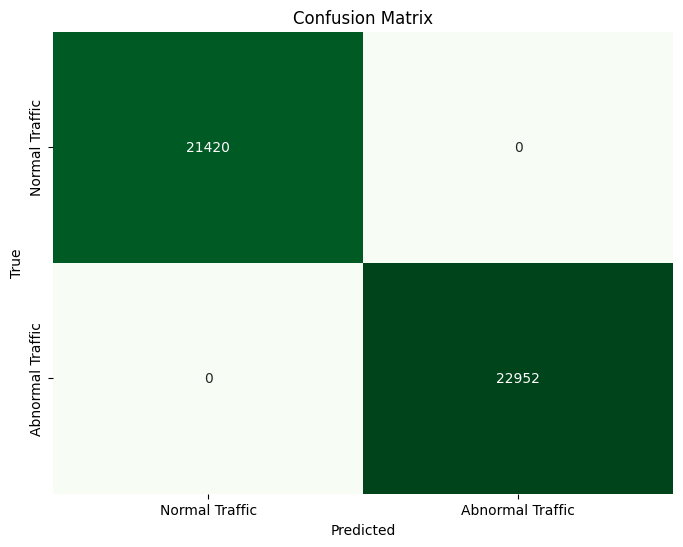

In [70]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_dtm = confusion_matrix(y_test, y_pred_dtm)

# Define the class labels
class_labels = ['Normal Traffic', 'Abnormal Traffic']  # Adjust based on your actual classes

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dtm, annot=True, cmap='Greens', fmt='g', cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [71]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_SMOTE, y_train_SMOTE)
y_pred_rf = rf.predict(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Model Accuracy:", accuracy_rf)

Random Forest Model Accuracy: 1.0


In [72]:
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
class_report_rf = classification_report(y_test, y_pred_rf)
print(f"Accuracy: {accuracy_rf:.2f}")
print("\nConfusion Matrix:")
print(conf_matrix_rf)
print("\nClassification Report:")
print(class_report_rf)

Accuracy: 1.00

Confusion Matrix:
[[21420     0]
 [    0 22952]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     21420
           1       1.00      1.00      1.00     22952

    accuracy                           1.00     44372
   macro avg       1.00      1.00      1.00     44372
weighted avg       1.00      1.00      1.00     44372



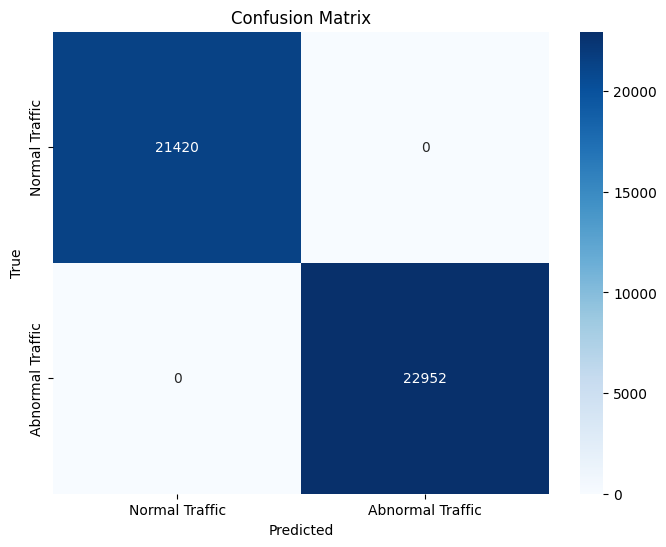

In [73]:
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, cmap='Blues', fmt='g',
            xticklabels=['Normal Traffic', 'Abnormal Traffic'], yticklabels=['Normal Traffic', 'Abnormal Traffic'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()